## DASC 5420 Exercise 2: Linear Regression (ISLP Chapter 3)
**Name: Asmita Bashyal**

**Student ID: T00781099**


---
## 3.6 Lab: Linear Regression

### 3.6.1 Importing packages

In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
%pip install ISLP
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)

Note: you may need to restart the kernel to use updated packages.


### 3.6.2 Simple Linear Regression

In [2]:
Boston = load_data("Boston")
Boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

In [3]:
X = pd.DataFrame({'intercept': np.ones(Boston.shape[0]),
                  'lstat': Boston['lstat']})
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [4]:
y = Boston['medv']
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,34.5538,0.563,61.415,0.0
lstat,-0.9500,0.039,-24.528,0.0


In [5]:
design = MS(['lstat'])
X = design.fit_transform(Boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [6]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           5.08e-88
Time:                        11:49:52   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [7]:
results.params

intercept    34.553841
lstat        -0.950049
dtype: float64

In [8]:
new_df = pd.DataFrame({'lstat':[5, 10, 15]})
newX = design.transform(new_df)
newX

,intercept,lstat
0,1.0,5
1,1.0,10
2,1.0,15


In [9]:
new_predictions = results.get_prediction(newX)
new_predictions.predicted_mean

array([29.80359411, 25.05334734, 20.30310057])

In [10]:
new_predictions.conf_int(alpha=0.05)

array([[29.00741194, 30.59977628],
       [24.47413202, 25.63256267],
       [19.73158815, 20.87461299]])

In [11]:
new_predictions.conf_int(obs=True, alpha=0.05)

array([[17.56567478, 42.04151344],
       [12.82762635, 37.27906833],
       [ 8.0777421 , 32.52845905]])

In [12]:
def abline(ax, b, m, *args, **kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)

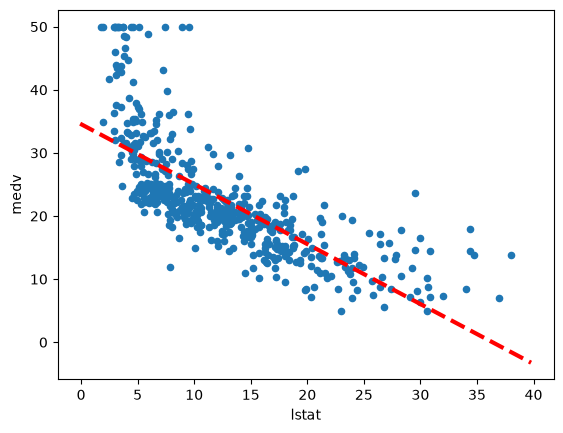

In [13]:
ax = Boston.plot.scatter('lstat', 'medv')
abline(ax,
       results.params['intercept'],
       results.params['lstat'],
       'r--',
       linewidth=3)

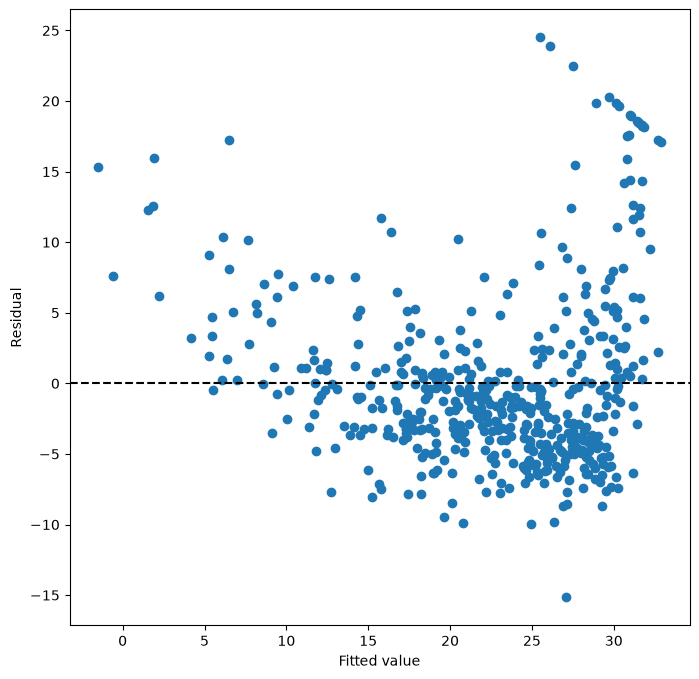

In [14]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

The residual plot has a curve (U shape), so the relationship is not exactly linear.

np.int64(374)

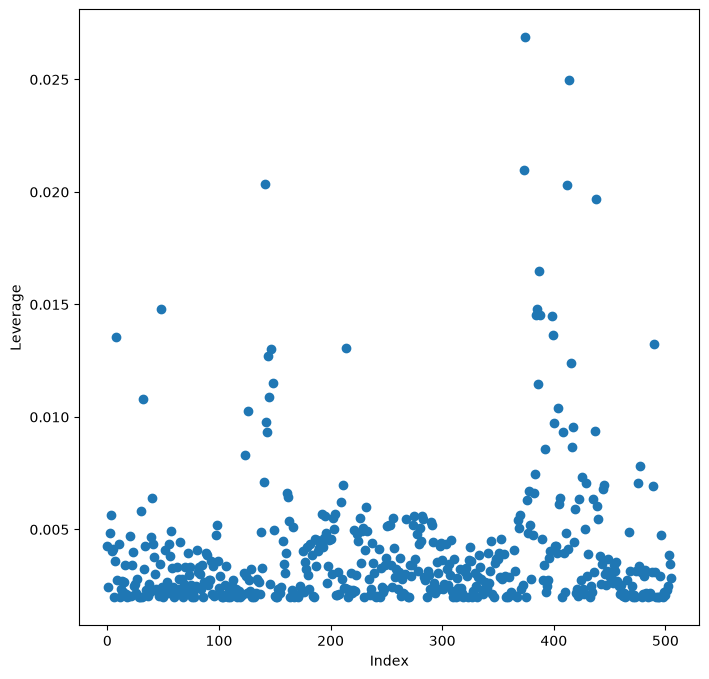

In [15]:
infl = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

### 3.6.3 Multiple Linear Regression

In [16]:
X = MS(['lstat', 'age']).fit_transform(Boston)
model1 = sm.OLS(y, X)
results1 = model1.fit()
summarize(results1)

,coef,std err,t,P>|t|
intercept,33.2228,0.731,45.458,0.000
lstat,-1.0321,0.048,-21.416,0.000
age,0.0345,0.012,2.826,0.005


In [17]:
terms = Boston.columns.drop('medv')
terms

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat'],
      dtype='object')

In [18]:
X = MS(terms).fit_transform(Boston)
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,41.6173,4.936,8.431,0.000
crim,-0.1214,0.033,-3.678,0.000
zn,0.0470,0.014,3.384,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8400,0.870,3.264,0.001
nox,-18.7580,3.851,-4.870,0.000
rm,3.6581,0.420,8.705,0.000
age,0.0036,0.013,0.271,0.787
dis,-1.4908,0.202,-7.394,0.000
rad,0.2894,0.067,4.325,0.000


In [19]:
minus_age = Boston.columns.drop(['medv', 'age'])
Xma = MS(minus_age).fit_transform(Boston)
model1 = sm.OLS(y, Xma)
summarize(model1.fit())

,coef,std err,t,P>|t|
intercept,41.5251,4.920,8.441,0.000
crim,-0.1214,0.033,-3.683,0.000
zn,0.0465,0.014,3.379,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8528,0.868,3.287,0.001
nox,-18.4851,3.714,-4.978,0.000
rm,3.6811,0.411,8.951,0.000
dis,-1.5068,0.193,-7.825,0.000
rad,0.2879,0.067,4.322,0.000
tax,-0.0127,0.004,-3.333,0.001


### 3.6.4 Multivariate Goodness of Fit

In [20]:
results.rsquared

np.float64(0.7343070437613076)

In [21]:
np.sqrt(results.scale)

np.float64(4.798034335596367)

In [22]:
vals = [VIF(X, i)
        for i in range(1, X.shape[1])]
vif = pd.DataFrame({'vif':vals},
                   index=X.columns[1:])
vif

,vif
crim,1.767486
zn,2.298459
indus,3.987181
chas,1.071168
nox,4.369093
rm,1.912532
age,3.088232
dis,3.954037
rad,7.445301
tax,9.002158


In [23]:
vals = []
for i in range(1, X.values.shape[1]):
    vals.append(VIF(X.values, i))
vals

[np.float64(1.7674859154310125),
 np.float64(2.2984589077358093),
 np.float64(3.9871806307570976),
 np.float64(1.071167773758404),
 np.float64(4.369092622844797),
 np.float64(1.9125324374368864),
 np.float64(3.0882320397311966),
 np.float64(3.954036641628298),
 np.float64(7.445300760069838),
 np.float64(9.002157663471797),
 np.float64(1.7970595931297797),
 np.float64(2.8707765008417496)]

### 3.6.5 Interaction Terms

In [24]:
X = MS(['lstat',
        'age',
        ('lstat', 'age')]).fit_transform(Boston)
model2 = sm.OLS(y, X)
summarize(model2.fit())

,coef,std err,t,P>|t|
intercept,36.0885,1.470,24.553,0.000
lstat,-1.3921,0.167,-8.313,0.000
age,-0.0007,0.020,-0.036,0.971
lstat:age,0.0042,0.002,2.244,0.025


### 3.6.6 Non-linear Transformations of the Predictors

In [25]:
X = MS([poly('lstat', degree=2), 'age']).fit_transform(Boston)
model3 = sm.OLS(y, X)
results3 = model3.fit()
summarize(results3)

,coef,std err,t,P>|t|
intercept,17.7151,0.781,22.681,0.0
"poly(lstat, degree=2)[0]",-179.2279,6.733,-26.620,0.0
"poly(lstat, degree=2)[1]",72.9908,5.482,13.315,0.0
age,0.0703,0.011,6.471,0.0


In [26]:
anova_lm(results1, results3)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,503.0,19168.128609,0.0,NaN,NaN,NaN
1,502.0,14165.613251,1.0,5002.515357,177.278785,7.468491e-35


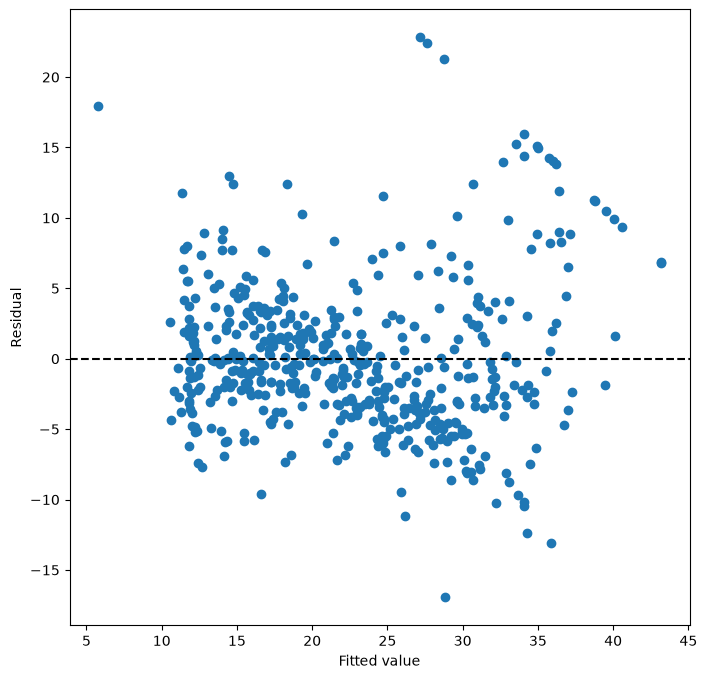

In [27]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results3.fittedvalues, results3.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

After adding `lstat` squared, the residual plot shows much less of a pattern.

### 3.6.7 Qualitative Predictors

In [28]:
Carseats = load_data('Carseats')
Carseats.columns

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')

In [29]:
allvars = list(Carseats.columns.drop('Sales'))
y = Carseats['Sales']
final = allvars + [('Income', 'Advertising'),
                   ('Price', 'Age')]
X = MS(final).fit_transform(Carseats)
model = sm.OLS(y, X)
summarize(model.fit())

,coef,std err,t,P>|t|
intercept,6.5756,1.009,6.519,0.000
CompPrice,0.0929,0.004,22.567,0.000
Income,0.0109,0.003,4.183,0.000
Advertising,0.0702,0.023,3.107,0.002
Population,0.0002,0.000,0.433,0.665
Price,-0.1008,0.007,-13.549,0.000
ShelveLoc[Good],4.8487,0.153,31.724,0.000
ShelveLoc[Medium],1.9533,0.126,15.531,0.000
Age,-0.0579,0.016,-3.633,0.000
Education,-0.0209,0.020,-1.063,0.288


---
## Exercise 1

Table 3.4 (Advertising data):

| | Coefficient | Std. error | t-statistic | p-value |
|---|---|---|---|---|
| Intercept | 2.939 | 0.3119 | 9.42 | < 0.0001 |
| TV | 0.046 | 0.0014 | 32.81 | < 0.0001 |
| radio | 0.189 | 0.0086 | 21.89 | < 0.0001 |
| newspaper | −0.001 | 0.0059 | −0.18 | 0.8599 |

**The model:**

$$\text{sales} = \beta_0 + \beta_1 \times \text{TV} + \beta_2 \times \text{radio} + \beta_3 \times \text{newspaper} + \epsilon$$

Each p-value in the table tests one null hypothesis.

---

**Intercept**

$$H_0: \beta_0 = 0 \qquad \text{vs} \qquad H_a: \beta_0 \neq 0$$

$H_0$ says: with no TV, radio or newspaper advertising, sales are zero.

p-value $< 0.0001$, so we **reject $H_0$**.

Even with no advertising at all, sales are not zero. They are about 2,939 units.

---

**TV**

$$H_0: \beta_1 = 0 \qquad \text{vs} \qquad H_a: \beta_1 \neq 0$$

$H_0$ says: when radio and newspaper spending stay the same, TV advertising is not associated with sales.

p-value $< 0.0001$, so we **reject $H_0$**.

TV advertising is related to sales. Each extra \$1,000 on TV goes with about 46 more units sold.

---

**Radio**

$$H_0: \beta_2 = 0 \qquad \text{vs} \qquad H_a: \beta_2 \neq 0$$

$H_0$ says: when TV and newspaper spending stay the same, radio advertising is not associated with sales.

p-value $< 0.0001$, so we **reject $H_0$**.

Radio advertising is related to sales. Each extra \$1,000 on radio goes with about 189 more units sold.

---

**Newspaper**

$$H_0: \beta_3 = 0 \qquad \text{vs} \qquad H_a: \beta_3 \neq 0$$

$H_0$ says: when TV and radio spending stay the same, newspaper advertising is not associated with sales.

p-value $= 0.8599$, which is greater than $0.05$, so we **fail to reject $H_0$**.

There is no evidence that newspaper advertising is associated with sales once TV and radio are already in the model.

---

**Conclusion:** TV and radio advertising are both related to higher sales. Newspaper advertising is not.

## Exercise 7

Show that in simple linear regression, $R^2 = r^2$, where $r = Cor(X, Y)$.

Let us assume $\bar x = 0$ and $\bar y = 0$.

---
### Step 1: Definitions

Least squares estimates:
$$\hat\beta_1 = \frac{\sum_{i=1}^{n}(x_i - \bar x)(y_i - \bar y)}{\sum_{i=1}^{n}(x_i - \bar x)^2}, \qquad \hat\beta_0 = \bar y - \hat\beta_1 \bar x$$

Fitted values:
$$\hat y_i = \hat\beta_0 + \hat\beta_1 x_i$$

Residual sum of squares:
$$RSS = \sum_{i=1}^{n}(y_i - \hat y_i)^2$$

Total sum of squares:
$$TSS = \sum_{i=1}^{n}(y_i - \bar y)^2$$

Coefficient of determination:
$$R^2 = 1 - \frac{RSS}{TSS} = \frac{TSS - RSS}{TSS}$$

Correlation between $X$ and $Y$:
$$r = \frac{\sum_{i=1}^{n}(x_i - \bar x)(y_i - \bar y)}{\sqrt{\sum_{i=1}^{n}(x_i - \bar x)^2}\;\sqrt{\sum_{i=1}^{n}(y_i - \bar y)^2}}$$

---

### Step 2: Simplify $\hat\beta_1$, $\hat\beta_0$ and $\hat y_i$ using $\bar x = \bar y = 0$

Since $\bar x = 0$ and $\bar y = 0$, we have $x_i - \bar x = x_i$ and $y_i - \bar y = y_i$. So:

$$\hat\beta_1 = \frac{\sum_{i=1}^{n} x_i y_i}{\sum_{i=1}^{n} x_i^2}$$

$$\hat\beta_0 = \bar y - \hat\beta_1 \bar x = 0 - \hat\beta_1 \times 0 = 0$$

Because the intercept is 0, the fitted values are:
$$\hat y_i = \hat\beta_1 x_i$$

---

### Step 3: Simplify TSS

Since $\bar y = 0$:
$$TSS = \sum_{i=1}^{n}(y_i - 0)^2 = \sum_{i=1}^{n} y_i^2$$

---

### Step 4: Simplify RSS

Substitute $\hat y_i = \hat\beta_1 x_i$:
$$RSS = \sum_{i=1}^{n}(y_i - \hat\beta_1 x_i)^2$$

Expand the square using $(a - b)^2 = a^2 - 2ab + b^2$:
$$RSS = \sum_{i=1}^{n}\left(y_i^2 - 2\hat\beta_1 x_i y_i + \hat\beta_1^2 x_i^2\right)$$

Split the sum into three sums. $\hat\beta_1$ is a single number, so it comes out in front of the sum:
$$RSS = \sum_{i=1}^{n} y_i^2 \;-\; 2\hat\beta_1 \sum_{i=1}^{n} x_i y_i \;+\; \hat\beta_1^2 \sum_{i=1}^{n} x_i^2$$

Now substitute $\hat\beta_1 = \dfrac{\sum x_i y_i}{\sum x_i^2}$ into the second and third terms.

Second term:
$$2\hat\beta_1 \sum_{i=1}^{n} x_i y_i = 2 \cdot \frac{\sum x_i y_i}{\sum x_i^2} \cdot \sum x_i y_i = \frac{2\left(\sum x_i y_i\right)^2}{\sum x_i^2}$$

Third term:
$$\hat\beta_1^2 \sum_{i=1}^{n} x_i^2 = \frac{\left(\sum x_i y_i\right)^2}{\left(\sum x_i^2\right)^2} \cdot \sum x_i^2 = \frac{\left(\sum x_i y_i\right)^2}{\sum x_i^2}$$

Put them back into RSS:
$$RSS = \sum_{i=1}^{n} y_i^2 \;-\; \frac{2\left(\sum x_i y_i\right)^2}{\sum x_i^2} \;+\; \frac{\left(\sum x_i y_i\right)^2}{\sum x_i^2}$$

The last two terms have the same denominator, and $-2 + 1 = -1$, so:
$$RSS = \sum_{i=1}^{n} y_i^2 \;-\; \frac{\left(\sum x_i y_i\right)^2}{\sum x_i^2}$$

---

### Step 5: Find TSS − RSS

$$TSS - RSS = \sum_{i=1}^{n} y_i^2 - \left(\sum_{i=1}^{n} y_i^2 - \frac{\left(\sum x_i y_i\right)^2}{\sum x_i^2}\right)$$

The $\sum y_i^2$ terms cancel:
$$TSS - RSS = \frac{\left(\sum x_i y_i\right)^2}{\sum x_i^2}$$

---

### Step 6: Find $R^2$

$$R^2 = \frac{TSS - RSS}{TSS} = \frac{\;\dfrac{\left(\sum x_i y_i\right)^2}{\sum x_i^2}\;}{\sum y_i^2}$$

Dividing by $\sum y_i^2$ is the same as multiplying the denominator by it:
$$R^2 = \frac{\left(\sum_{i=1}^{n} x_i y_i\right)^2}{\left(\sum_{i=1}^{n} x_i^2\right)\left(\sum_{i=1}^{n} y_i^2\right)}$$

---

### Step 7: Find $r^2$

Since $\bar x = \bar y = 0$, the correlation becomes:
$$r = \frac{\sum_{i=1}^{n} x_i y_i}{\sqrt{\sum_{i=1}^{n} x_i^2}\;\sqrt{\sum_{i=1}^{n} y_i^2}}$$

Square both sides. Squaring a square root removes it:
$$r^2 = \frac{\left(\sum_{i=1}^{n} x_i y_i\right)^2}{\left(\sum_{i=1}^{n} x_i^2\right)\left(\sum_{i=1}^{n} y_i^2\right)}$$

---

### Step 8: Compare

The result of Step 6 and the result of Step 7 are exactly the same expression. Therefore:

$$\boxed{R^2 = r^2 = \left[Cor(X, Y)\right]^2}$$

**In words:** in simple linear regression, the fraction of the variation in $Y$ explained by the line ($R^2$) is equal to the square of the correlation between $X$ and $Y$.

---
## Exercise 8

### (a)

In [30]:
Auto = load_data('Auto')
Auto.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'year', 'origin'],
      dtype='object')

In [31]:
X = MS(['horsepower']).fit_transform(Auto)
y = Auto['mpg']
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,39.9359,0.717,55.660,0.0
horsepower,-0.1578,0.006,-24.489,0.0


In [32]:
results.rsquared

np.float64(0.6059482578894348)

In [33]:
design = MS(['horsepower'])
design = design.fit(Auto)
new_df = pd.DataFrame({'horsepower': [98]})
newX = design.transform(new_df)
new_predictions = results.get_prediction(newX)
new_predictions.predicted_mean

array([24.46707715])

In [34]:
new_predictions.conf_int(alpha=0.05)

array([[23.97307896, 24.96107534]])

In [35]:
new_predictions.conf_int(obs=True, alpha=0.05)

array([[14.80939607, 34.12475823]])

i. Yes, there is a relationship. The p-value for horsepower is about 0.

ii. The relationship is fairly strong. $R^2 = 0.606$, so horsepower explains about 61% of the variation in mpg.

iii. The relationship is negative (coefficient = −0.158). More horsepower means lower mpg.

iv. For horsepower = 98, the predicted mpg is 24.47.
- 95% confidence interval: (23.97, 24.96)
- 95% prediction interval: (14.81, 34.12)

### (b)

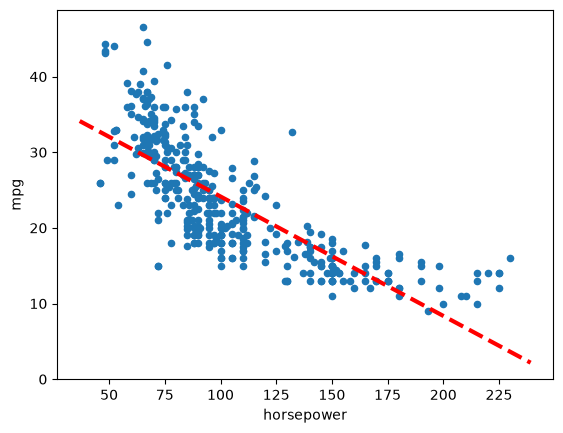

In [36]:
ax = Auto.plot.scatter('horsepower', 'mpg')
abline(ax,
       results.params['intercept'],
       results.params['horsepower'],
       'r--',
       linewidth=3)

### (c)

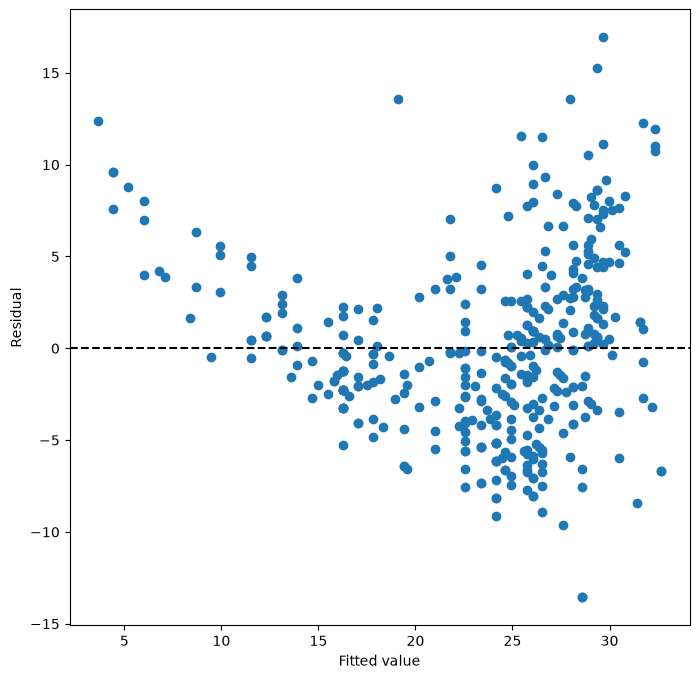

In [37]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

np.int64(115)

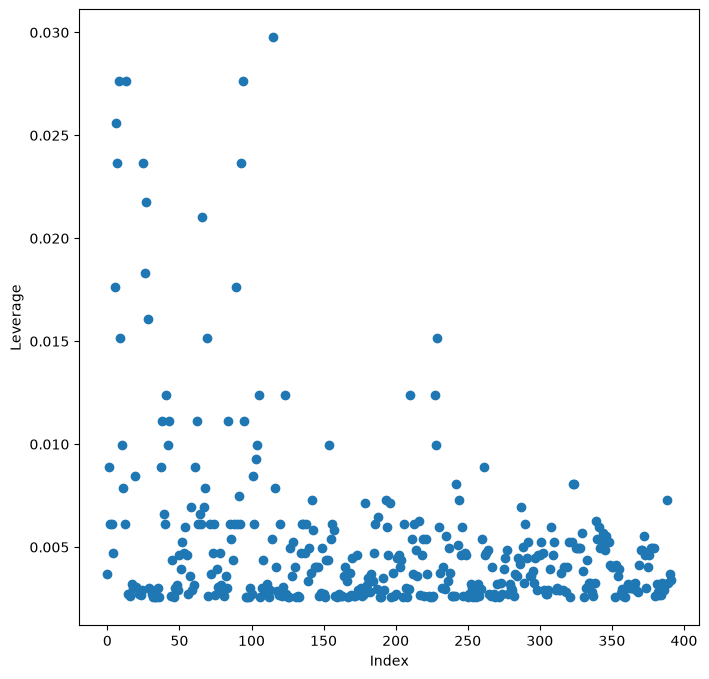

In [38]:
infl = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

In [39]:
p = X.shape[1] - 1
n = X.shape[0]
stud = infl.resid_studentized_external
print('average leverage (p+1)/n =', round((p + 1) / n, 4))
print('max leverage =', round(infl.hat_matrix_diag.max(), 4))
print('max |studentized residual| =', round(np.abs(stud).max(), 3))
print('number with |studentized residual| > 3:', np.sum(np.abs(stud) > 3))

average leverage (p+1)/n = 0.0051
max leverage = 0.0298
max |studentized residual| = 3.509
number with |studentized residual| > 3: 2


The residual plot has a U shape. This means the relationship between mpg and horsepower is not linear. The residuals are also more spread out for larger fitted values.

Using the measures from ISLP Section 3.3.3:
- **Outliers:** 2 observations have a studentized residual with |value| > 3 (largest 3.51), so there are a couple of possible outliers.
- **Leverage:** the average leverage is (p+1)/n = 2/392 = 0.0051. The largest leverage (index 115) is 0.0298, about 6 times the average. So a few cars with very high or very low horsepower have noticeably high leverage.

---
## Exercise 9

### (a)

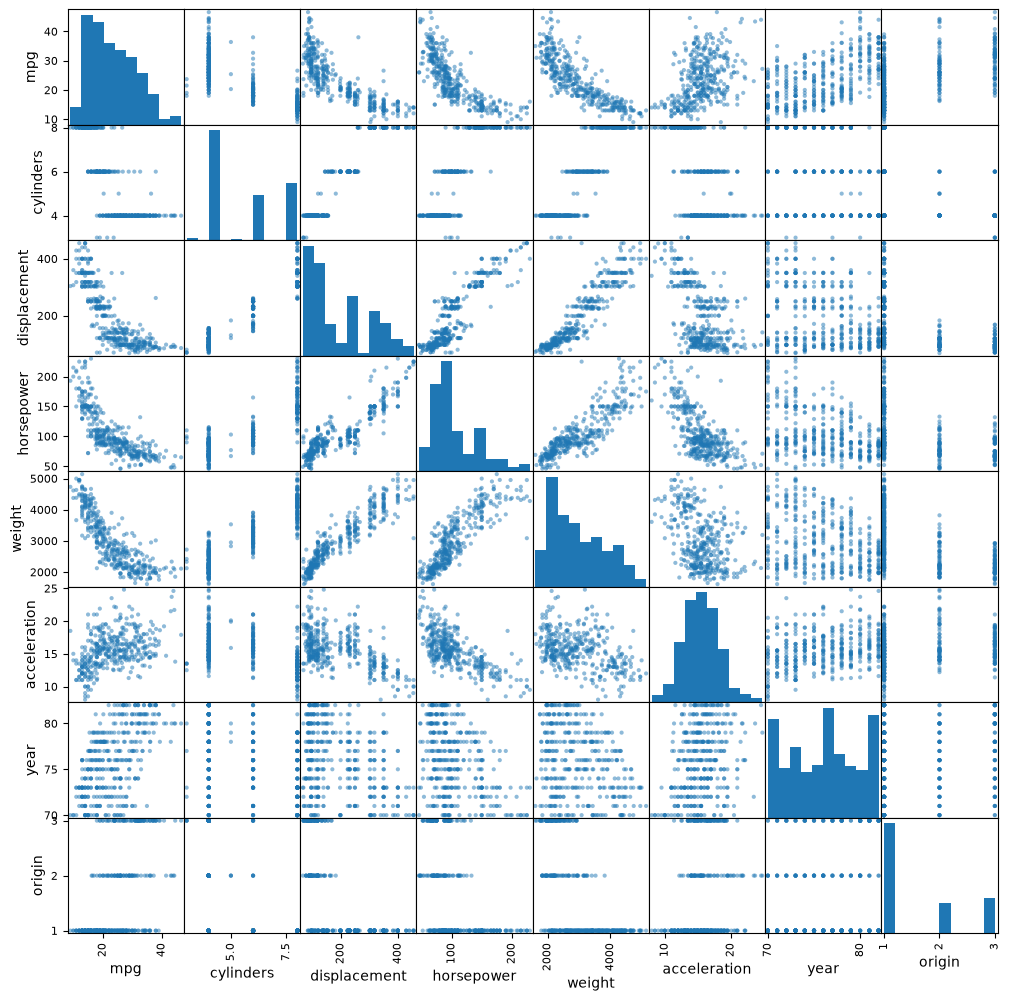

In [40]:
pd.plotting.scatter_matrix(Auto, figsize=(12, 12));

### (b)

In [41]:
Auto.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


### (c)

In [42]:
terms = Auto.columns.drop('mpg')
X = MS(terms).fit_transform(Auto)
y = Auto['mpg']
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,-17.2184,4.644,-3.707,0.000
cylinders,-0.4934,0.323,-1.526,0.128
displacement,0.0199,0.008,2.647,0.008
horsepower,-0.0170,0.014,-1.230,0.220
weight,-0.0065,0.001,-9.929,0.000
acceleration,0.0806,0.099,0.815,0.415
year,0.7508,0.051,14.729,0.000
origin,1.4261,0.278,5.127,0.000


In [43]:
X0 = MS([]).fit_transform(Auto)
results0 = sm.OLS(y, X0).fit()
anova_lm(results0, results)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,391.0,23818.993469,0.0,NaN,NaN,NaN
1,384.0,4252.212530,7.0,19566.780939,252.428045,2.037106e-139


i. Yes. The ANOVA F-test has a p-value of about 0, so at least one predictor is related to mpg.

ii. `displacement`, `weight`, `year` and `origin` are statistically significant (p-value < 0.05). `cylinders`, `horsepower` and `acceleration` are not.

iii. The coefficient for `year` is 0.75. This means that each year newer, cars get about 0.75 more mpg, when the other variables stay the same.

**Note:** `origin` is coded 1/2/3 (American, European, Japanese), but it is a category, not a quantity. Treating it as a number assumes the effect of going from 1 to 2 equals going from 2 to 3. A better model would code it as a qualitative predictor (dummy variables).

### (d)

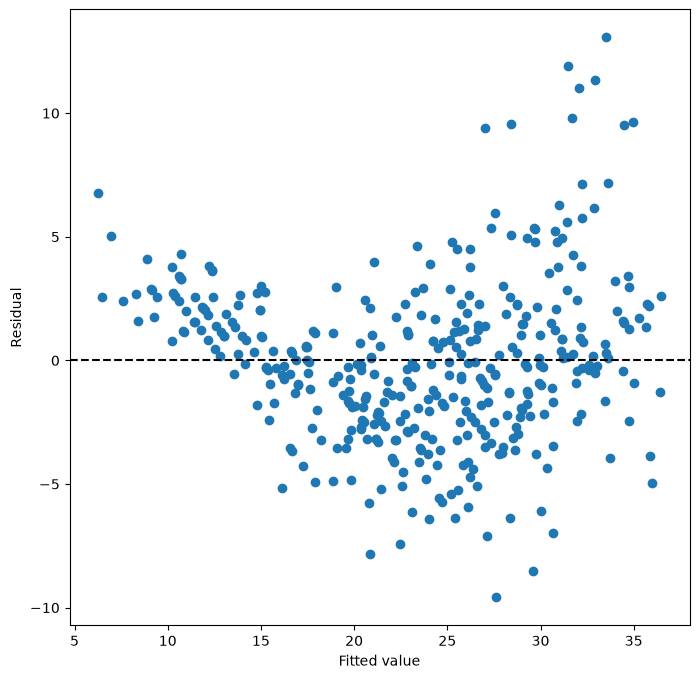

In [44]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

np.int64(13)

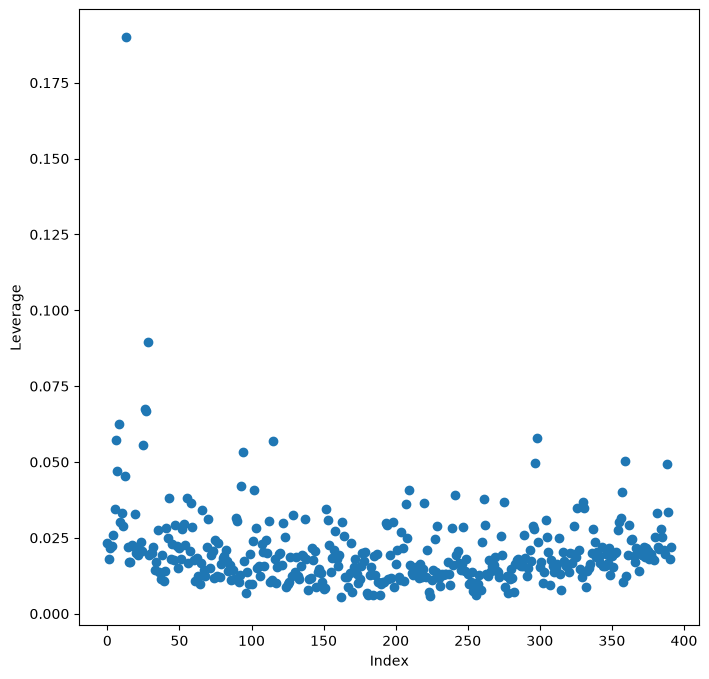

In [45]:
infl = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

In [46]:
Auto.index[13]

'buick estate wagon (sw)'

average leverage (p+1)/n = 0.0204
max leverage = 0.1899
number with |studentized residual| > 3: 4


Index(['volkswagen rabbit custom diesel', 'mazda glc', 'vw rabbit c (diesel)',
       'vw dasher (diesel)'],
      dtype='object', name='name')

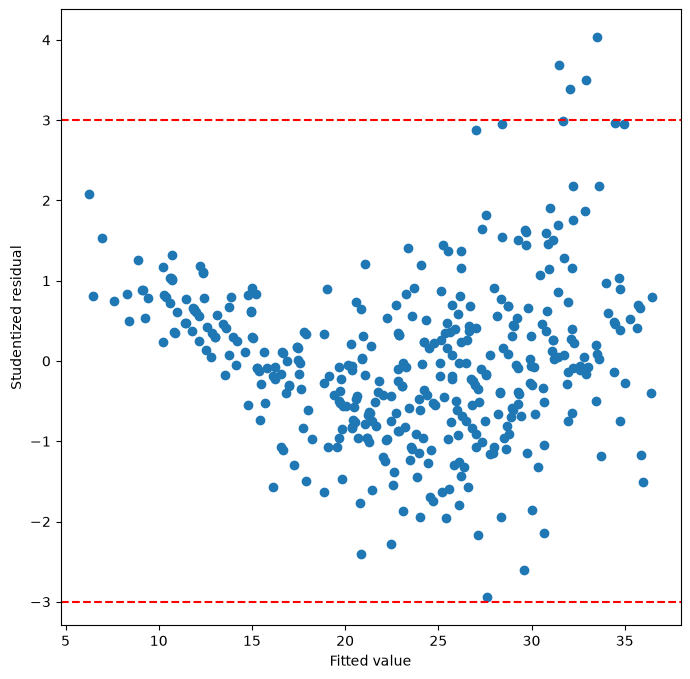

In [47]:
p = X.shape[1] - 1
n = X.shape[0]
stud = infl.resid_studentized_external
ax = subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues, stud)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Studentized residual')
ax.axhline(3, c='r', ls='--')
ax.axhline(-3, c='r', ls='--')
print('average leverage (p+1)/n =', round((p + 1) / n, 4))
print('max leverage =', round(infl.hat_matrix_diag.max(), 4))
print('number with |studentized residual| > 3:', np.sum(np.abs(stud) > 3))
Auto.index[np.abs(stud) > 3]

The residual plot still has a slight U shape, so the fit is not perfectly linear.

Using studentized residuals and the average leverage:
- **Outliers:** 4 cars have |studentized residual| > 3. They are all light, fuel-efficient cars (three VW diesels and a Mazda GLC) whose mpg is higher than the model predicts.
- **Leverage:** the average leverage is (p+1)/n = 8/392 = 0.0204. The buick estate wagon (index 13) has leverage 0.190, about 9 times the average, so it is a high-leverage point.

In [48]:
X = MS(['horsepower',
        'weight',
        ('horsepower', 'weight')]).fit_transform(Auto)
model = sm.OLS(y, X)
summarize(model.fit())

,coef,std err,t,P>|t|
intercept,63.557900,2.343000,27.127,0.0
horsepower,-0.250800,0.027000,-9.195,0.0
weight,-0.010800,0.001000,-13.921,0.0
horsepower:weight,0.000054,0.000007,8.054,0.0


In [49]:
X = MS(['displacement',
        'year',
        ('displacement', 'year')]).fit_transform(Auto)
model = sm.OLS(y, X)
summarize(model.fit())

,coef,std err,t,P>|t|
intercept,-72.8784,8.368,-8.709,0.0
displacement,0.2523,0.041,6.216,0.0
year,1.4077,0.110,12.779,0.0
displacement:year,-0.0041,0.001,-7.482,0.0


Both interactions, `horsepower:weight` and `displacement:year`, have p-values close to 0, so they are statistically significant.

### (f)

In [50]:
Auto['log_horsepower'] = np.log(Auto['horsepower'])
Auto['sqrt_horsepower'] = np.sqrt(Auto['horsepower'])
Auto['horsepower2'] = Auto['horsepower'] ** 2

In [51]:
X = MS(['horsepower']).fit_transform(Auto)
results_hp = sm.OLS(y, X).fit()
results_hp.rsquared

np.float64(0.6059482578894348)

In [52]:
X = MS(['log_horsepower']).fit_transform(Auto)
results_log = sm.OLS(y, X).fit()
results_log.rsquared

np.float64(0.6683347641192137)

In [53]:
X = MS(['sqrt_horsepower']).fit_transform(Auto)
results_sqrt = sm.OLS(y, X).fit()
results_sqrt.rsquared

np.float64(0.6437035832706475)

In [54]:
X = MS(['horsepower', 'horsepower2']).fit_transform(Auto)
results_sq = sm.OLS(y, X).fit()
summarize(results_sq)

,coef,std err,t,P>|t|
intercept,56.9001,1.800,31.604,0.0
horsepower,-0.4662,0.031,-14.978,0.0
horsepower2,0.0012,0.000,10.080,0.0


In [55]:
results_sq.rsquared

np.float64(0.6875590305127517)

In [56]:
print('adjusted R^2:')
for label, res in [('horsepower', results_hp), ('log(horsepower)', results_log),
                   ('sqrt(horsepower)', results_sqrt), ('horsepower + horsepower^2', results_sq)]:
    print(' ', label, round(res.rsquared_adj, 4))
anova_lm(results_hp, results_sq)

adjusted R^2:
  horsepower 0.6049
  log(horsepower) 0.6675
  sqrt(horsepower) 0.6428
  horsepower + horsepower^2 0.686


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,390.0,9385.915872,0.0,NaN,NaN,NaN
1,389.0,7442.029412,1.0,1943.88646,101.608283,2.196340e-21


| Model | $R^2$ | Adjusted $R^2$ |
|---|---|---|
| horsepower | 0.606 | 0.605 |
| log(horsepower) | 0.668 | 0.668 |
| sqrt(horsepower) | 0.644 | 0.643 |
| horsepower + horsepower² | 0.688 | 0.686 |

The quadratic model has one more parameter than the others, so its $R^2$ is guaranteed to be at least as high as the linear model. Adjusted $R^2$ penalises the extra parameter, and the quadratic model is still the best (0.686). The ANOVA test comparing the linear and quadratic models gives F = 101.6 with p-value ≈ $2 \times 10^{-21}$, so adding horsepower² is a real improvement.

All three transformations fit better than plain horsepower. This agrees with the curved residual plot in Exercise 8.

---
## Exercise 10

### (a)

In [57]:
Carseats = load_data('Carseats')
X = MS(['Price', 'Urban', 'US']).fit_transform(Carseats)
y = Carseats['Sales']
model = sm.OLS(y, X)
results_a = model.fit()
summarize(results_a)

,coef,std err,t,P>|t|
intercept,13.0435,0.651,20.036,0.000
Price,-0.0545,0.005,-10.389,0.000
Urban[Yes],-0.0219,0.272,-0.081,0.936
US[Yes],1.2006,0.259,4.635,0.000


### (b)
- **Price:** when price goes up by \$1, sales go down by about 0.054 thousand (54 car seats).
- **Urban[Yes]:** urban stores sell about 0.022 thousand (22 seats) fewer than rural stores. The p-value is large, so this is not significant.
- **US[Yes]:** stores in the US sell about 1.2 thousand (1,200 seats) more than stores outside the US.

### (c)
$$Sales = 13.04 - 0.054 \times Price - 0.022 \times Urban + 1.20 \times US$$

where Urban = 1 if the store is urban (0 if not), and US = 1 if the store is in the US (0 if not).

### (d)
We can reject $H_0: \beta_j = 0$ for **Price** and **US**.

### (e)

In [58]:
X = MS(['Price', 'US']).fit_transform(Carseats)
model = sm.OLS(y, X)
results_e = model.fit()
summarize(results_e)

,coef,std err,t,P>|t|
intercept,13.0308,0.631,20.652,0.0
Price,-0.0545,0.005,-10.416,0.0
US[Yes],1.1996,0.258,4.641,0.0


### (f)

In [59]:
results_a.rsquared, results_e.rsquared

(np.float64(0.23927539218405525), np.float64(0.23926288842678567))

In [60]:
anova_lm(results_e, results_a)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,397.0,2420.874462,0.0,NaN,NaN,NaN
1,396.0,2420.834671,1.0,0.03979,0.006509,0.935739


Both models have $R^2 \approx 0.239$, so each explains only about 24% of the variation in sales. The ANOVA p-value is 0.94, so removing `Urban` makes no difference. The smaller model (e) is just as good.

### (g)

In [61]:
results_e.conf_int(alpha=0.05)

,0,1
intercept,11.79032,14.271265
Price,-0.06476,-0.044195
US[Yes],0.69152,1.707766


### (h)

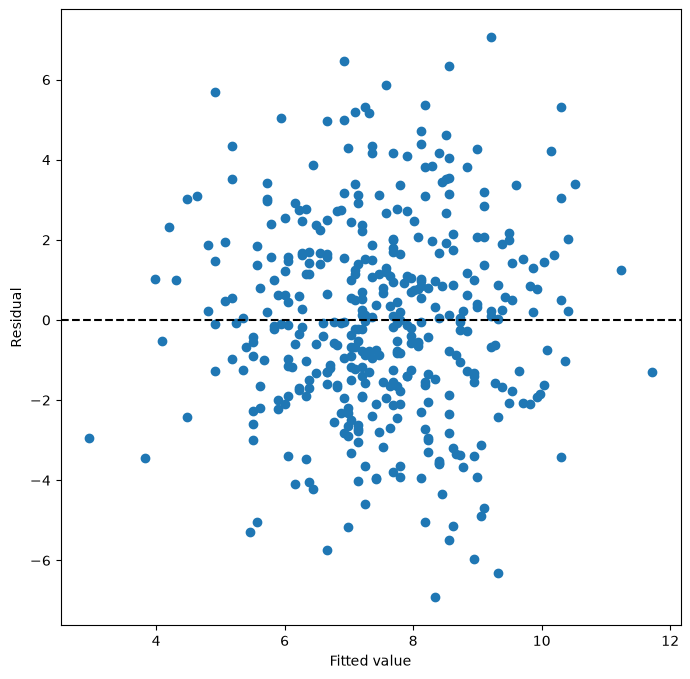

In [62]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results_e.fittedvalues, results_e.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

np.int64(42)

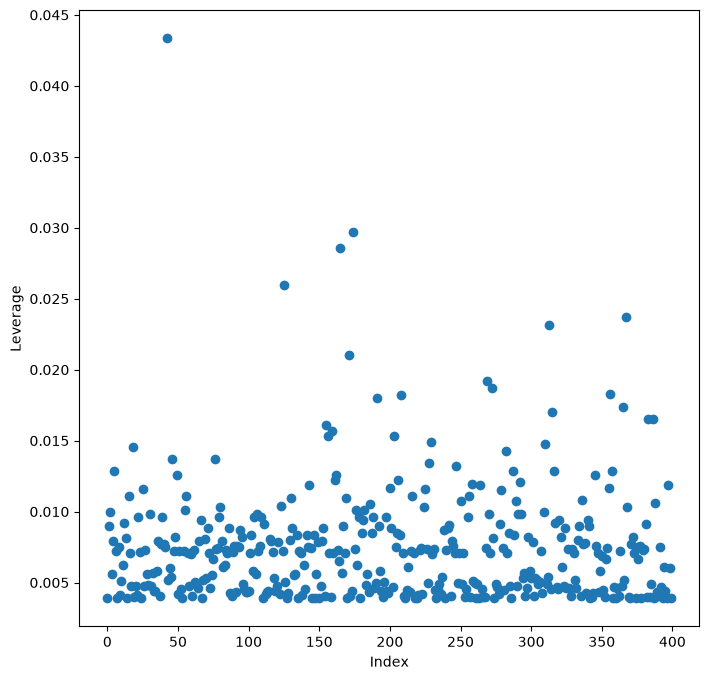

In [63]:
infl = results_e.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

In [64]:
p = X.shape[1] - 1
n = X.shape[0]
stud = infl.resid_studentized_external
print('average leverage (p+1)/n =', round((p + 1) / n, 4))
print('max leverage =', round(infl.hat_matrix_diag.max(), 4))
print('max |studentized residual| =', round(np.abs(stud).max(), 3))
print('number with |studentized residual| > 3:', np.sum(np.abs(stud) > 3))

average leverage (p+1)/n = 0.0075
max leverage = 0.0433
max |studentized residual| = 2.892
number with |studentized residual| > 3: 0


The residual plot shows no clear pattern. No observation has |studentized residual| > 3 (the largest is 2.89), so there is no evidence of outliers.

The average leverage is (p+1)/n = 3/400 = 0.0075. The largest leverage (index 42) is 0.043, about 6 times the average, so there are a few high-leverage observations.

---
## Exercise 11

In [65]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = 2 * x + rng.normal(size=100)

### (a)

In [66]:
df = pd.DataFrame({'x': x, 'y': y})
X = MS(['x'], intercept=False).fit_transform(df)
model = sm.OLS(df['y'], X)
results_yx = model.fit()
summarize(results_yx)

,coef,std err,t,P>|t|
x,1.9762,0.117,16.898,0.0


$\hat\beta = 1.976$, standard error = 0.117, t-statistic = 16.90, p-value ≈ 0. We reject $H_0: \beta = 0$. The estimate is close to the true value of 2.

### (b)

In [67]:
X = MS(['y'], intercept=False).fit_transform(df)
model = sm.OLS(df['x'], X)
results_xy = model.fit()
summarize(results_xy)

,coef,std err,t,P>|t|
y,0.3757,0.022,16.898,0.0


$\hat\beta = 0.376$, standard error = 0.022, t-statistic = 16.90, p-value ≈ 0. We reject $H_0: \beta = 0$.

### (c)
The coefficients are different, but the t-statistic (16.90) and the p-value are the same in (a) and (b).

### (d)

Show that for the regression of $Y$ onto $X$ without an intercept,
$$t = \frac{\sqrt{n-1}\,\sum_{i=1}^{n} x_i y_i}{\sqrt{\left(\sum_{i=1}^{n} x_i^2\right)\left(\sum_{i'=1}^{n} y_{i'}^2\right) - \left(\sum_{i'=1}^{n} x_{i'} y_{i'}\right)^2}}$$

---

#### Step 1: Given

The coefficient estimate (equation 3.38):
$$\hat\beta = \frac{\sum_{i=1}^{n} x_i y_i}{\sum_{i=1}^{n} x_i^2}$$

The standard error:
$$SE(\hat\beta) = \sqrt{\frac{\sum_{i=1}^{n}(y_i - x_i\hat\beta)^2}{(n-1)\sum_{i'=1}^{n} x_{i'}^2}}$$

The t-statistic:
$$t = \frac{\hat\beta}{SE(\hat\beta)}$$

(The index $i'$ is just another name for $i$. Both run from 1 to $n$, so $\sum_{i'} x_{i'}^2$ is the same as $\sum_i x_i^2$.)

---

#### Step 2: Simplify the top part of the SE, $\sum (y_i - x_i\hat\beta)^2$

Expand the square using $(a - b)^2 = a^2 - 2ab + b^2$:
$$\sum_{i=1}^{n}(y_i - x_i\hat\beta)^2 = \sum_{i=1}^{n}\left(y_i^2 - 2\hat\beta x_i y_i + \hat\beta^2 x_i^2\right)$$

Split into three sums. $\hat\beta$ is a single number, so it comes out in front of the sum:
$$= \sum_{i=1}^{n} y_i^2 \;-\; 2\hat\beta \sum_{i=1}^{n} x_i y_i \;+\; \hat\beta^2 \sum_{i=1}^{n} x_i^2$$

Substitute $\hat\beta = \dfrac{\sum x_i y_i}{\sum x_i^2}$ into the second term:
$$2\hat\beta \sum_{i=1}^{n} x_i y_i = 2 \cdot \frac{\sum x_i y_i}{\sum x_i^2} \cdot \sum x_i y_i = \frac{2\left(\sum x_i y_i\right)^2}{\sum x_i^2}$$

Substitute it into the third term:
$$\hat\beta^2 \sum_{i=1}^{n} x_i^2 = \frac{\left(\sum x_i y_i\right)^2}{\left(\sum x_i^2\right)^2} \cdot \sum x_i^2 = \frac{\left(\sum x_i y_i\right)^2}{\sum x_i^2}$$

Put them back together. The last two terms have the same denominator, and $-2 + 1 = -1$:
$$\sum_{i=1}^{n}(y_i - x_i\hat\beta)^2 = \sum_{i=1}^{n} y_i^2 \;-\; \frac{\left(\sum x_i y_i\right)^2}{\sum x_i^2}$$

Write it as one fraction by multiplying the first term by $\dfrac{\sum x_i^2}{\sum x_i^2}$:
$$\sum_{i=1}^{n}(y_i - x_i\hat\beta)^2 = \frac{\left(\sum x_i^2\right)\left(\sum y_i^2\right) - \left(\sum x_i y_i\right)^2}{\sum x_i^2}$$

---

#### Step 3: Put this into the SE formula

$$SE(\hat\beta) = \sqrt{\frac{\;\dfrac{\left(\sum x_i^2\right)\left(\sum y_i^2\right) - \left(\sum x_i y_i\right)^2}{\sum x_i^2}\;}{(n-1)\sum x_i^2}}$$

Dividing by $(n-1)\sum x_i^2$ is the same as multiplying the denominator by it. The denominator now has $\sum x_i^2$ twice:
$$SE(\hat\beta) = \sqrt{\frac{\left(\sum x_i^2\right)\left(\sum y_i^2\right) - \left(\sum x_i y_i\right)^2}{(n-1)\left(\sum x_i^2\right)^2}}$$

Take the square root of the top and the bottom separately. Since $\sum x_i^2 > 0$, we have $\sqrt{\left(\sum x_i^2\right)^2} = \sum x_i^2$:
$$SE(\hat\beta) = \frac{\sqrt{\left(\sum x_i^2\right)\left(\sum y_i^2\right) - \left(\sum x_i y_i\right)^2}}{\sqrt{n-1}\;\sum x_i^2}$$

---

#### Step 4: Find $t = \hat\beta \,/\, SE(\hat\beta)$

$$t = \frac{\hat\beta}{SE(\hat\beta)} = \frac{\;\dfrac{\sum x_i y_i}{\sum x_i^2}\;}{\;\dfrac{\sqrt{\left(\sum x_i^2\right)\left(\sum y_i^2\right) - \left(\sum x_i y_i\right)^2}}{\sqrt{n-1}\;\sum x_i^2}\;}$$

Dividing by a fraction is the same as multiplying by its reciprocal (flip it upside down):
$$t = \frac{\sum x_i y_i}{\sum x_i^2} \times \frac{\sqrt{n-1}\;\sum x_i^2}{\sqrt{\left(\sum x_i^2\right)\left(\sum y_i^2\right) - \left(\sum x_i y_i\right)^2}}$$

$\sum x_i^2$ appears once on the bottom and once on the top, so it cancels:
$$t = \frac{\sqrt{n-1}\;\sum x_i y_i}{\sqrt{\left(\sum x_i^2\right)\left(\sum y_i^2\right) - \left(\sum x_i y_i\right)^2}}$$

---

#### Step 5: Conclusion

$$\boxed{t = \frac{\sqrt{n-1}\,\sum_{i=1}^{n} x_i y_i}{\sqrt{\left(\sum_{i=1}^{n} x_i^2\right)\left(\sum_{i'=1}^{n} y_{i'}^2\right) - \left(\sum_{i'=1}^{n} x_{i'} y_{i'}\right)^2}}}$$

This is the formula given in the question.

**Check with numbers:** compute this formula in Python with the $x$ and $y$ from (a).

In [68]:
n = 100
t = (np.sqrt(n - 1) * np.sum(x * y)) / np.sqrt(np.sum(x**2) * np.sum(y**2) - np.sum(x * y)**2)
t

np.float64(16.898417063035094)

This matches the t-statistic from (a).

### (e)
If we swap $x$ and $y$ in the formula from (d), it stays the same. So the t-statistic for y onto x equals the t-statistic for x onto y.

### (f)

In [69]:
X = MS(['x']).fit_transform(df)
results1 = sm.OLS(df['y'], X).fit()
results1.tvalues

intercept    -0.756096
x            16.734055
dtype: float64

In [70]:
X = MS(['y']).fit_transform(df)
results2 = sm.OLS(df['x'], X).fit()
results2.tvalues

intercept     0.216082
y            16.734055
dtype: float64

With an intercept, the t-statistic for the slope is 16.73 in both regressions, so they are the same.

---
## Exercise 13

### (a)

In [71]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)

### (b)
A variance of 0.25 means a standard deviation of 0.5.

In [72]:
eps = rng.normal(loc=0, scale=0.5, size=100)

### (c)

In [73]:
y = -1 + 0.5 * x + eps
len(y)

100

The length of y is 100. $\beta_0 = -1$ and $\beta_1 = 0.5$.

### (d)

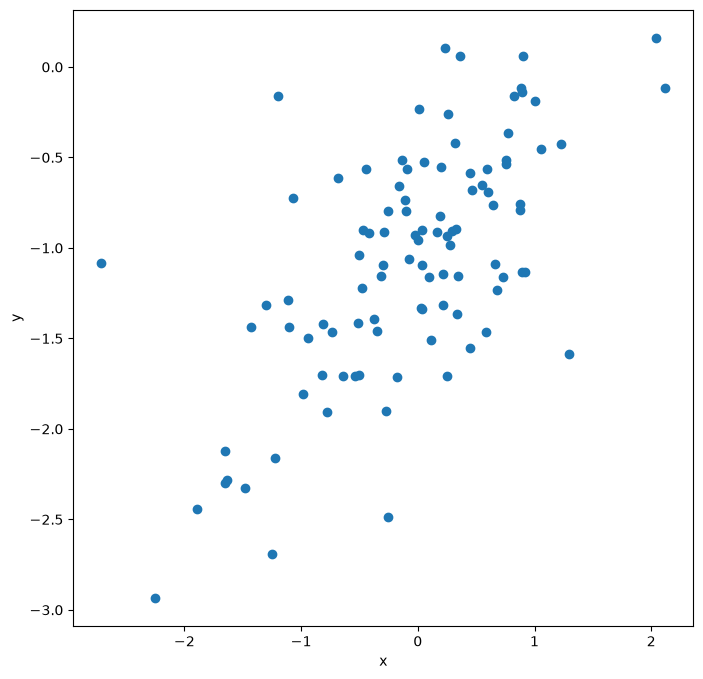

In [74]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(x, y)
ax.set_xlabel('x')
ax.set_ylabel('y');

There is a positive, linear relationship between x and y, with some noise.

### (e)

In [75]:
df = pd.DataFrame({'x': x, 'y': y})
X = MS(['x']).fit_transform(df)
model = sm.OLS(df['y'], X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,-1.0380,0.050,-20.647,0.0
x,0.4843,0.059,8.233,0.0


$\hat\beta_0 = -1.04$ and $\hat\beta_1 = 0.48$. These are very close to the true values $\beta_0 = -1$ and $\beta_1 = 0.5$.

### (f)

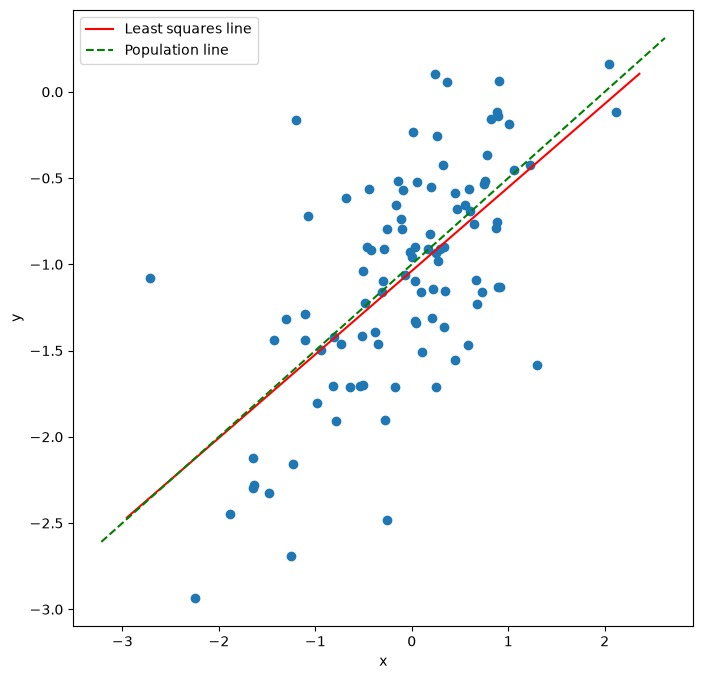

In [76]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(x, y)
abline(ax, results.params['intercept'], results.params['x'], 'r', label='Least squares line')
abline(ax, -1, 0.5, 'g--', label='Population line')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend();

### (g)

In [77]:
X2 = MS([poly('x', degree=2, raw=True)]).fit_transform(df)
model2 = sm.OLS(df['y'], X2)
results2 = model2.fit()
summarize(results2)

,coef,std err,t,P>|t|
intercept,-1.0364,0.060,-17.399,0.000
"poly(x, degree=2, raw=True)[0]",0.4831,0.063,7.647,0.000
"poly(x, degree=2, raw=True)[1]",-0.0024,0.045,-0.052,0.959


In [78]:
anova_lm(results, results2)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,98.0,24.586567,0.0,NaN,NaN,NaN
1,97.0,24.585886,1.0,0.000681,0.002688,0.958757


The p-value for $x^2$ is 0.96, so there is no evidence that the quadratic term improves the model.

### (h) Less noise (variance = 0.01, standard deviation = 0.1)

In [79]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
eps = rng.normal(loc=0, scale=0.1, size=100)
y = -1 + 0.5 * x + eps
df_less = pd.DataFrame({'x': x, 'y': y})
X = MS(['x']).fit_transform(df_less)
results_less = sm.OLS(df_less['y'], X).fit()
summarize(results_less)

,coef,std err,t,P>|t|
intercept,-1.0076,0.010,-100.209,0.0
x,0.4969,0.012,42.236,0.0


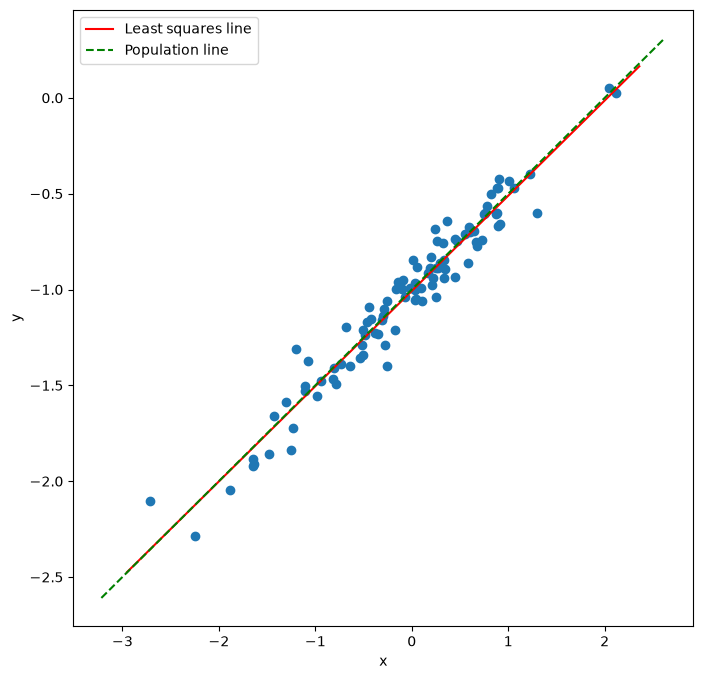

In [80]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(x, y)
abline(ax, results_less.params['intercept'], results_less.params['x'], 'r', label='Least squares line')
abline(ax, -1, 0.5, 'g--', label='Population line')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend();

With less noise, the points are very close to the line. The estimates ($-1.008$ and $0.497$) are closer to the true values, and the standard errors are smaller. The two lines are almost the same.

Because `rng` is reset to seed 1 each time, (h) and (i) use the same $x$ and the same standard-normal draws as the original data, only scaled by a different standard deviation. So the noise level is the only thing that changes between the three fits.

### (i) More noise (variance = 1, standard deviation = 1)

In [81]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
eps = rng.normal(loc=0, scale=1, size=100)
y = -1 + 0.5 * x + eps
df_more = pd.DataFrame({'x': x, 'y': y})
X = MS(['x']).fit_transform(df_more)
results_more = sm.OLS(df_more['y'], X).fit()
summarize(results_more)

,coef,std err,t,P>|t|
intercept,-1.0760,0.101,-10.701,0.0
x,0.4686,0.118,3.983,0.0


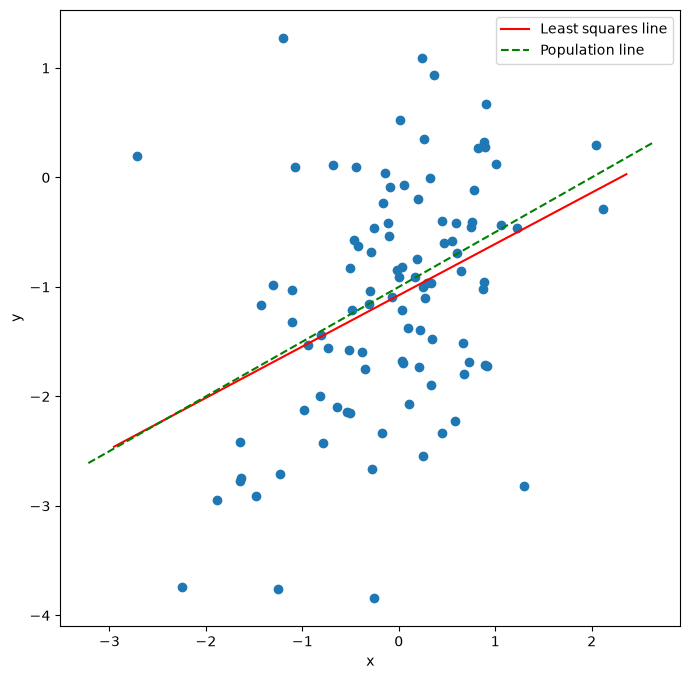

In [82]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(x, y)
abline(ax, results_more.params['intercept'], results_more.params['x'], 'r', label='Least squares line')
abline(ax, -1, 0.5, 'g--', label='Population line')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend();

With more noise, the points are much more spread out. The estimates ($-1.076$ and $0.469$) are further from the true values, and the standard errors are larger.

### (j)

In [83]:
results.conf_int(alpha=0.05)

,0,1
intercept,-1.137782,-0.938244
x,0.367565,0.601017


In [84]:
results_less.conf_int(alpha=0.05)

,0,1
intercept,-1.027556,-0.987649
x,0.473513,0.520203


In [85]:
results_more.conf_int(alpha=0.05)

,0,1
intercept,-1.275564,-0.876487
x,0.235131,0.702033


| Data | CI for $\beta_0$ | CI for $\beta_1$ |
|---|---|---|
| Original | (−1.138, −0.938) | (0.368, 0.601) |
| Less noise | (−1.028, −0.988) | (0.474, 0.520) |
| More noise | (−1.276, −0.876) | (0.235, 0.702) |

All the intervals contain the true values. More noise gives wider intervals, and less noise gives narrower intervals.

---
## Exercise 15

### (a)

In [86]:
Boston = load_data('Boston')
y = Boston['crim']
predictors = Boston.columns.drop('crim')
predictors

Index(['zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

In [87]:
simple_coef = []
for name in predictors:
    X = MS([name]).fit_transform(Boston)
    results = sm.OLS(y, X).fit()
    simple_coef.append(results.params[name])
    print(name, ' coef =', round(results.params[name], 4), ' p-value =', round(results.pvalues[name], 4))

zn  coef = -0.0739  p-value = 0.0
indus  coef = 0.5098  p-value = 0.0
chas  coef = -1.8928  p-value = 0.2094
nox  coef = 31.2485  p-value = 0.0
rm  coef = -2.6841  p-value = 0.0
age  coef = 0.1078  p-value = 0.0
dis  coef = -1.5509  p-value = 0.0
rad  coef = 0.6179  p-value = 0.0
tax  coef = 0.0297  p-value = 0.0
ptratio  coef = 1.152  p-value = 0.0
lstat  coef = 0.5488  p-value = 0.0
medv  coef = -0.3632  p-value = 0.0


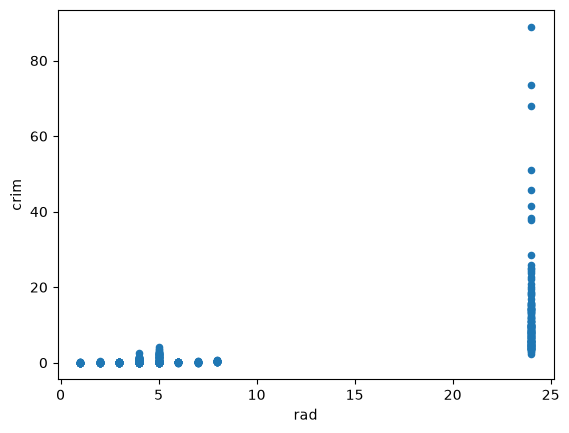

In [88]:
ax = Boston.plot.scatter('rad', 'crim')

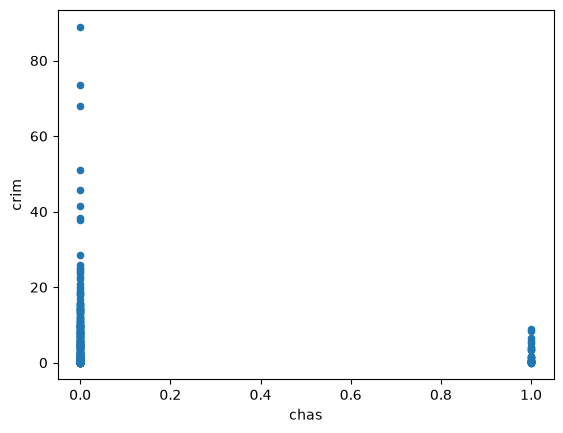

In [89]:
ax = Boston.plot.scatter('chas', 'crim')

Every predictor except `chas` has a significant association with `crim` (p-value < 0.05). For example, the plot shows that crime is much higher when `rad` = 24. For `chas` there is no clear difference between 0 and 1.

### (b)

In [90]:
X = MS(predictors).fit_transform(Boston)
results_all = sm.OLS(y, X).fit()
summarize(results_all)

,coef,std err,t,P>|t|
intercept,13.7784,7.082,1.946,0.052
zn,0.0457,0.019,2.433,0.015
indus,-0.0584,0.084,-0.698,0.486
chas,-0.8254,1.183,-0.697,0.486
nox,-9.9576,5.290,-1.882,0.060
rm,0.6289,0.607,1.036,0.301
age,-0.0008,0.018,-0.047,0.962
dis,-1.0122,0.282,-3.584,0.000
rad,0.6125,0.088,6.997,0.000
tax,-0.0038,0.005,-0.730,0.466


We can reject $H_0: \beta_j = 0$ for `zn`, `dis`, `rad` and `medv` (p-value < 0.05). The other predictors are not significant when all of them are in the model together.

### (c)

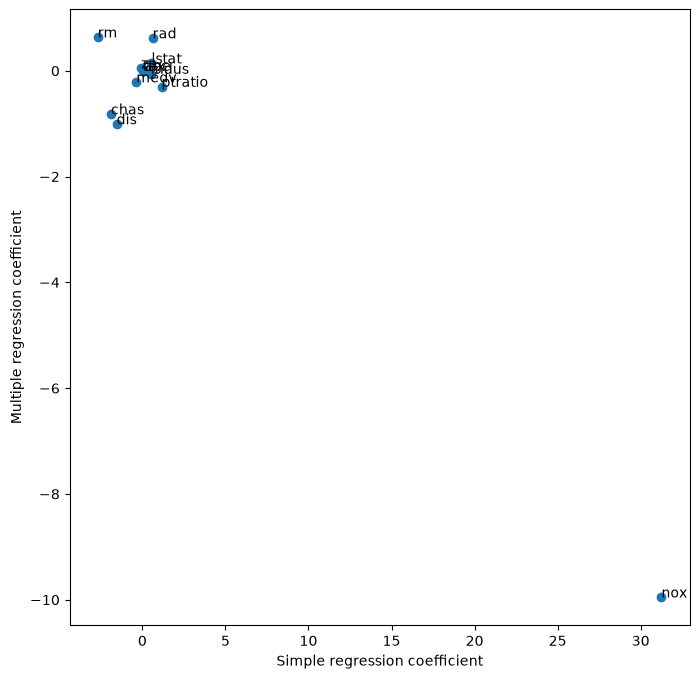

In [91]:
multiple_coef = results_all.params.iloc[1:]
ax = subplots(figsize=(8,8))[1]
ax.scatter(simple_coef, multiple_coef)
for name, sx, my in zip(predictors, simple_coef, multiple_coef):
    ax.annotate(name, (sx, my))
ax.set_xlabel('Simple regression coefficient')
ax.set_ylabel('Multiple regression coefficient');

In (a), 11 predictors were significant, but in (b) only 4 are. Some coefficients change a lot. For example, `nox` is about 31 in the simple regression but about −10 in the multiple regression. This happens because the predictors are correlated with each other.

The `nox` point is far from the others and sets the scale of the plot, so the other points are squeezed together near the origin.

### (d)

In [92]:
for name in predictors:
    if name == 'chas':
        continue
    X = MS([poly(name, degree=3)]).fit_transform(Boston)
    results = sm.OLS(y, X).fit()
    print(name, ' p-values:', np.round(results.pvalues.values[1:], 4))

zn  p-values: [0.     0.0044 0.2295]
indus  p-values: [0.     0.0011 0.    ]
nox  p-values: [0.     0.0001 0.    ]
rm  p-values: [0.     0.0015 0.5086]
age  p-values: [0.     0.     0.0067]
dis  p-values: [0. 0. 0.]
rad  p-values: [0.     0.0091 0.4823]
tax  p-values: [0.     0.     0.2439]
ptratio  p-values: [0.     0.0024 0.0063]
lstat  p-values: [0.     0.0378 0.1299]
medv  p-values: [0. 0. 0.]


The three p-values are for $X$, $X^2$ and $X^3$. (`chas` is skipped because it only takes the values 0 and 1.)

Yes, there is evidence of non-linear association:
- $X^2$ and $X^3$ are both significant for `indus`, `nox`, `age`, `dis`, `ptratio` and `medv`.
- Only $X^2$ is significant for `zn`, `rm`, `rad`, `tax` and `lstat`.

---
## Additional question: Exercise 14 (collinearity)

### (a)

In [93]:
rng = np.random.default_rng(10)
x1 = rng.uniform(0, 1, size=100)
x2 = 0.5 * x1 + rng.normal(size=100) / 10
y = 2 + 2 * x1 + 0.3 * x2 + rng.normal(size=100)

$Y = 2 + 2X_1 + 0.3X_2 + \epsilon$, so $\beta_0 = 2$, $\beta_1 = 2$ and $\beta_2 = 0.3$.

### (b)

In [94]:
np.corrcoef(x1, x2)

array([[1.       , 0.7723245],
       [0.7723245, 1.       ]])

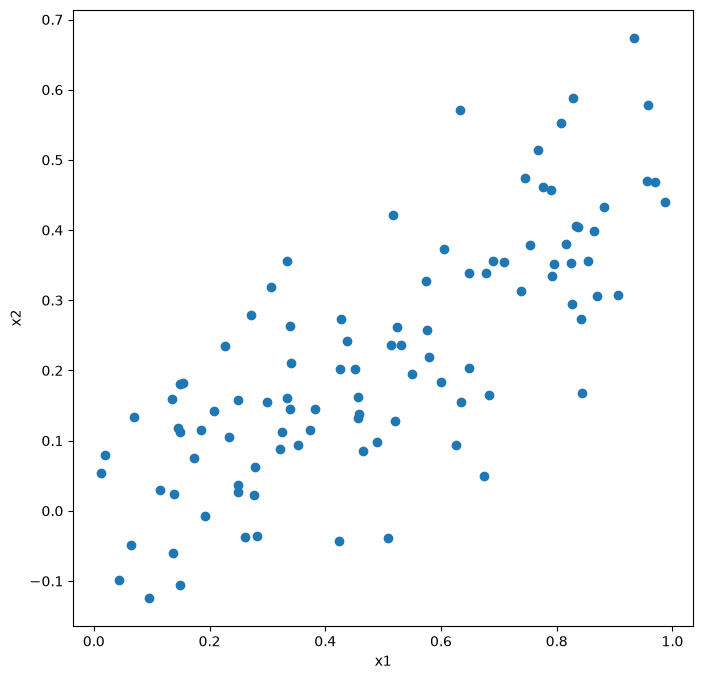

In [95]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(x1, x2)
ax.set_xlabel('x1')
ax.set_ylabel('x2');

The correlation is 0.77, so x1 and x2 are strongly related.

### (c)

In [96]:
df = pd.DataFrame({'x1': x1, 'x2': x2, 'y': y})
X = MS(['x1', 'x2']).fit_transform(df)
summarize(sm.OLS(df['y'], X).fit())

,coef,std err,t,P>|t|
intercept,1.9579,0.190,10.319,0.000
x1,1.6154,0.527,3.065,0.003
x2,0.9428,0.831,1.134,0.259


$\hat\beta_0 = 1.96$, $\hat\beta_1 = 1.62$, $\hat\beta_2 = 0.94$. Only $\hat\beta_0$ is close to its true value. We can reject $H_0: \beta_1 = 0$ (p = 0.003), but we cannot reject $H_0: \beta_2 = 0$ (p = 0.26).

### (d)

In [97]:
X = MS(['x1']).fit_transform(df)
summarize(sm.OLS(df['y'], X).fit())

,coef,std err,t,P>|t|
intercept,1.9371,0.189,10.242,0.0
x1,2.0771,0.335,6.196,0.0


x1 is significant (p ≈ 0), so we reject $H_0: \beta_1 = 0$.

### (e)

In [98]:
X = MS(['x2']).fit_transform(df)
summarize(sm.OLS(df['y'], X).fit())

,coef,std err,t,P>|t|
intercept,2.3239,0.154,15.124,0.0
x2,2.9103,0.550,5.291,0.0


x2 is significant (p ≈ 0), so we reject the null hypothesis that the coefficient on x2 is 0.

### (f)
The results do not contradict each other. Because x1 and x2 are highly correlated (collinearity), it is hard to separate their effects when both are in the same model. Each one alone is significant, but together one of them loses significance.

### (g)

In [99]:
x1 = np.concatenate([x1, [0.1]])
x2 = np.concatenate([x2, [0.8]])
y = np.concatenate([y, [6]])
df = pd.DataFrame({'x1': x1, 'x2': x2, 'y': y})

In [100]:
X = MS(['x1', 'x2']).fit_transform(df)
results_both = sm.OLS(df['y'], X).fit()
summarize(results_both)

,coef,std err,t,P>|t|
intercept,2.0618,0.192,10.720,0.000
x1,0.8575,0.466,1.838,0.069
x2,2.2663,0.705,3.216,0.002


In [101]:
X = MS(['x1']).fit_transform(df)
results_x1 = sm.OLS(df['y'], X).fit()
summarize(results_x1)

,coef,std err,t,P>|t|
intercept,2.0739,0.201,10.310,0.0
x1,1.8760,0.358,5.236,0.0


In [102]:
X = MS(['x2']).fit_transform(df)
results_x2 = sm.OLS(df['y'], X).fit()
summarize(results_x2)

,coef,std err,t,P>|t|
intercept,2.2840,0.151,15.088,0.0
x2,3.1458,0.524,6.008,0.0


np.int64(100)

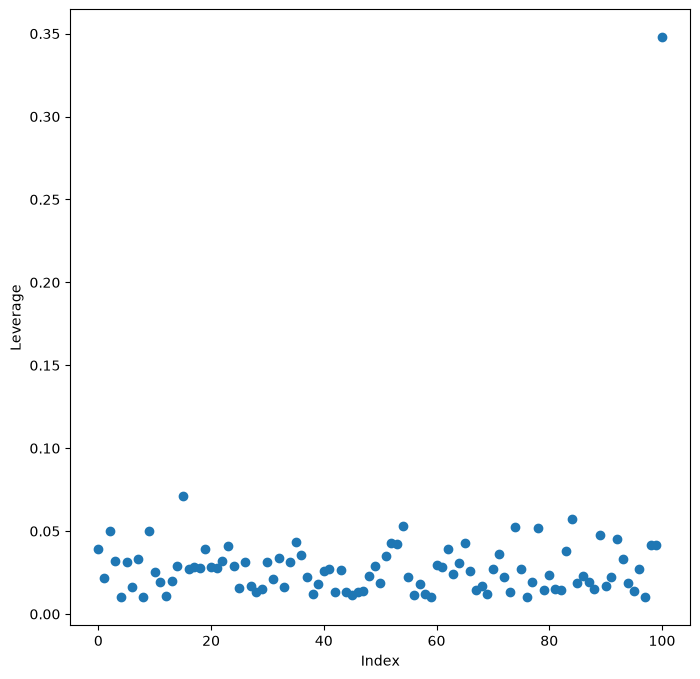

In [103]:
infl = results_both.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(101), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

In [104]:
# Leverage and studentized residual of the new point (index 100) in each model
rows = []
for label, res in [('x1 + x2', results_both), ('x1 only', results_x1), ('x2 only', results_x2)]:
    infl = res.get_influence()
    p = len(res.params) - 1
    rows.append({'model': label,
                 'leverage': infl.hat_matrix_diag[100],
                 'average leverage (p+1)/n': (p + 1) / 101,
                 'studentized residual': infl.resid_studentized_external[100]})
pd.DataFrame(rows).set_index('model').round(3)

,leverage,average leverage (p+1)/n,studentized residual
model,,,
x1 + x2,0.348,0.03,2.784
x1 only,0.030,0.02,4.179
x2 only,0.110,0.02,1.345


The average leverage is (p+1)/n = 3/101 = 0.030 for the model with both predictors and 2/101 = 0.020 for the single-predictor models.

- **Both predictors:** the coefficients change a lot. Now x2 is significant and x1 is not. The new point has leverage 0.348, more than 11 times the average, so it is a **high-leverage point**. Its studentized residual is 2.78, just under 3, so it is a borderline outlier at most.
- **x1 only:** the coefficient changes only a little. The leverage is 0.030, close to the average, because x1 = 0.1 is inside the range of the other x1 values. But the studentized residual is 4.18 > 3, so the point is an **outlier**.
- **x2 only:** the leverage is 0.110, about 5 times the average, because x2 = 0.8 is a large value. So it is a **high-leverage point**. The studentized residual is only 1.35, so it is not an outlier.

---
### Acknowledgement of AI use

I took help from AI (Claude) for the overall formatting of the assignment, for reviewing the code and answers, and for debugging the code wherever there was an error.

### References

1. James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer.
2. DASC 5420 Theoretical Machine Learning, lecture notes: *3. Linear Regression*.